## Clustering Assignment_15

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
#load Dataset
df=pd.read_excel('EastWestAirlines.xlsx',sheet_name='data')
#display dataset
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [27]:
#dataset information 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [28]:
#Dataset shape
df.shape

(3999, 12)

In [29]:
#Rename columns
df.rename(columns={'ID#': 'ID', 'Award?': 'Award'},inplace=True)

In [30]:
#Display data
df.head()

,ID,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


### Data Preprocessing:
#### 1.	Preprocess the dataset to handle missing values, remove outliers, and scale the features if necessary.


In [31]:
# Drop ID column
df = df.drop("ID", axis=1)

In [32]:
#check missing value and sum
df.isnull().sum()

Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award                0
dtype: int64

 No missing values → no imputation needed

In [33]:
#Remove low-variance features (based on heatmap insight)
df = df.drop(columns=["Qual_miles", "cc2_miles", "cc3_miles"])

In [34]:
# Remove outliers using IQR
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df_clean = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

# Reset index 
df_clean = df_clean.reset_index(drop=True)

In [35]:
# Feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_clean)

#### 2.	Perform exploratory data analysis (EDA) to gain insights into the distribution of data and identify potential clusters.

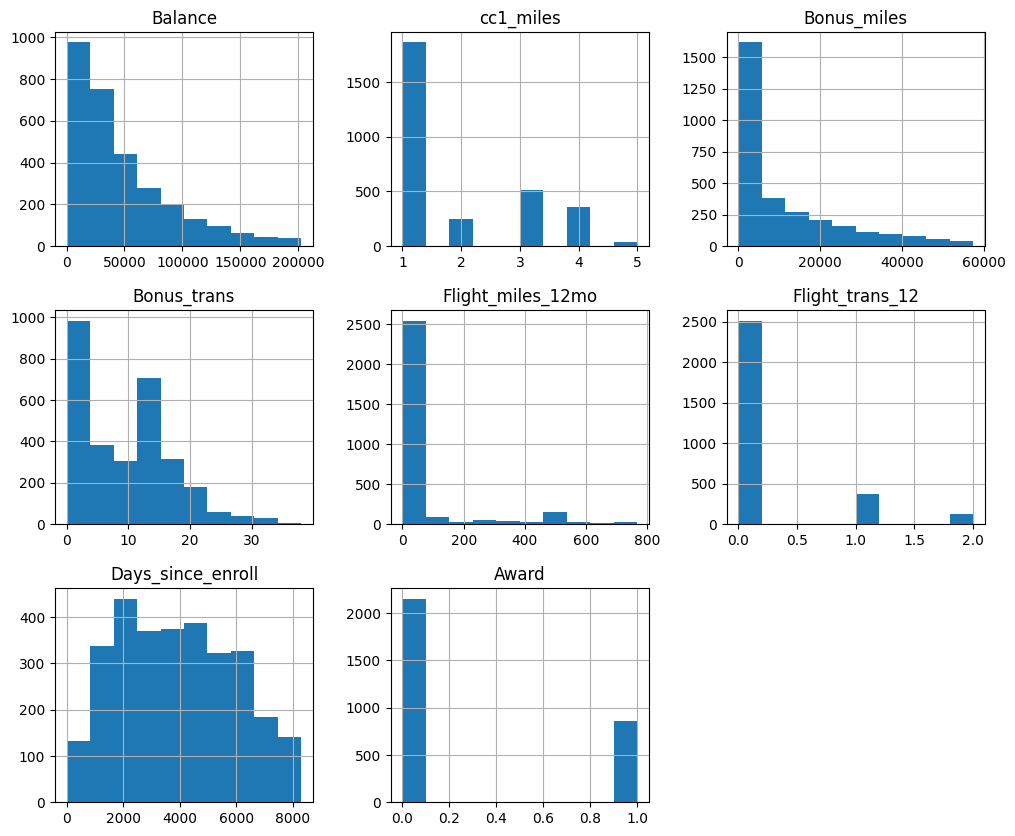

In [36]:
# Histograms
df_clean.hist(figsize=(12,10))
plt.show()

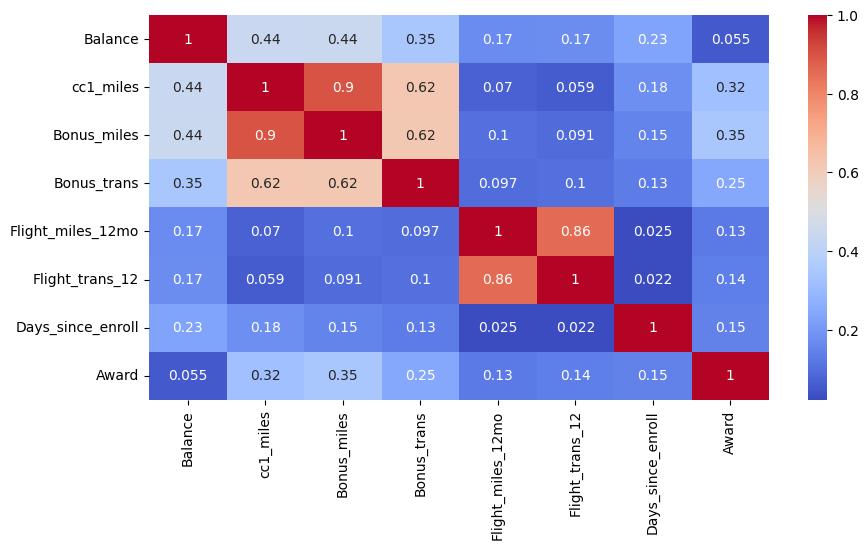

In [37]:
# Correlation heatmap
plt.figure(figsize=(10,5))
corr = df_clean.corr().fillna(0)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

#### 3.	Use multiple visualizations to understand the hidden patterns in the dataset


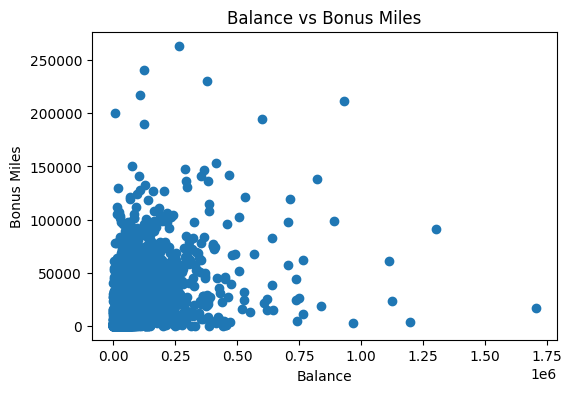

In [38]:
#1. Scatter Plot
plt.figure(figsize=(6,4))
plt.scatter(df["Balance"], df["Bonus_miles"])
plt.xlabel("Balance")
plt.ylabel("Bonus Miles")
plt.title("Balance vs Bonus Miles")
plt.show()

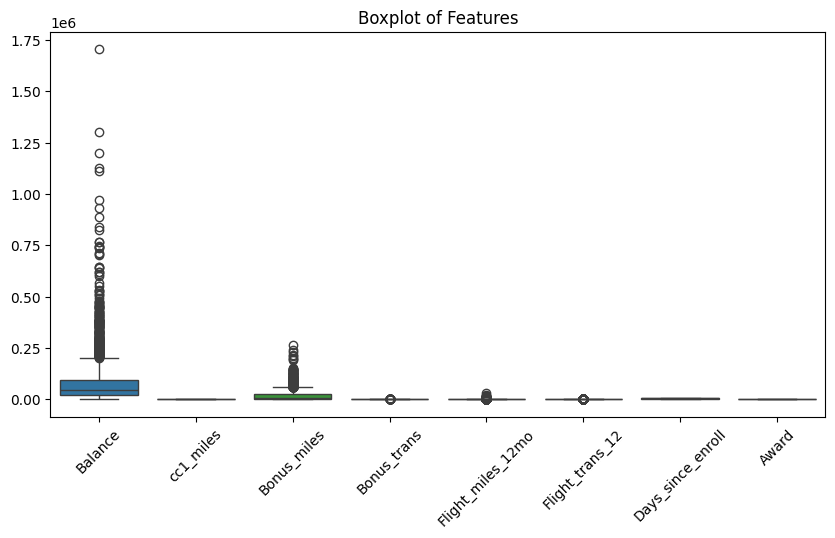

In [39]:
#2. Boxplot (Outlier detection)
plt.figure(figsize=(10,5))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Boxplot of Features")
plt.show()

### Implementing Clustering Algorithms:
#### Implement the K-Means and DBSCAN algorithms using a programming language such as Python with libraries like scikit-learn.



In [40]:
# K-Means
# Import required libraries
from sklearn.cluster import KMeans

# Apply K-Means 
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_data)

df_clean["KMeans_Cluster"] = kmeans_labels

# DBSCan
from sklearn.cluster import DBSCAN
# Apply DBScan 
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(scaled_data)

df_clean["DBSCAN_Cluster"] = dbscan_labels

#### Apply each clustering algorithm to the pre-processed dataset to identify clusters within the data.

#### Experiment with different parameter settings for K-means (Elbow curve for different K values) and DBSCAN (e.g., epsilon, minPts) and evaluate the clustering results

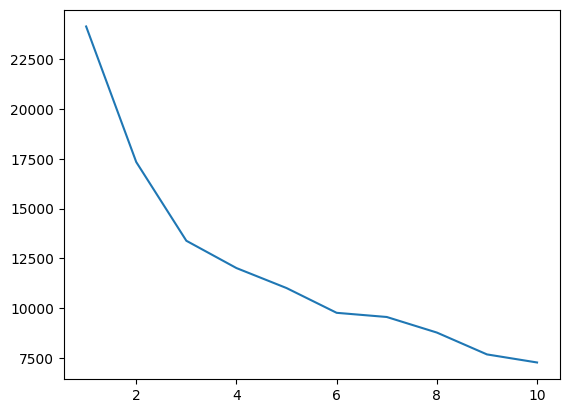

In [41]:
# Elbow method
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.show()

In [42]:
from sklearn.cluster import DBSCAN

# Trying different eps values
eps_values = [0.3, 0.5, 0.7]

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(scaled_data)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_points = list(labels).count(-1)
    
    print("EPS:", eps)
    print("Clusters:", n_clusters)
    print("Noise Points:", noise_points)
    print("----------------------")

EPS: 0.3
Clusters: 12
Noise Points: 1925
----------------------
EPS: 0.5
Clusters: 20
Noise Points: 1191
----------------------
EPS: 0.7
Clusters: 19
Noise Points: 745
----------------------


### Cluster Analysis and Interpretation:
#### Analyse the clusters generated by each clustering algorithm and interpret the characteristics of each cluster. Write you insights in few comments.


### Visualization:
#### Visualize the clustering results using scatter plots or other suitable visualization techniques.
#### Plot the clusters with different colours to visualize the separation of data points belonging to different clusters.

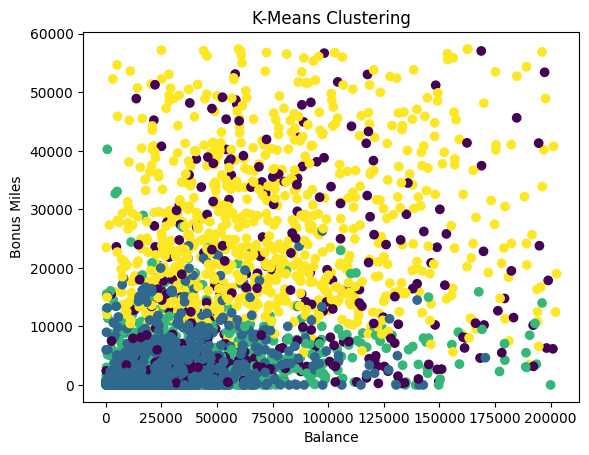

In [43]:
# K-Means Visualization
plt.scatter(df_clean["Balance"], df_clean["Bonus_miles"], 
            c=df_clean["KMeans_Cluster"])
plt.xlabel("Balance")
plt.ylabel("Bonus Miles")
plt.title("K-Means Clustering")
plt.show()

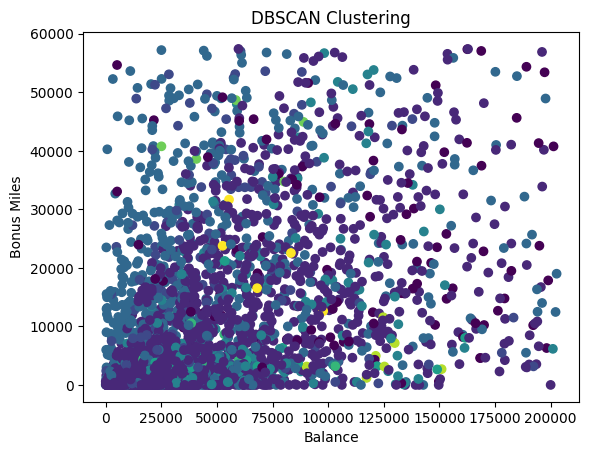

In [44]:
# DBSCAN Visualization
plt.scatter(df_clean["Balance"], df_clean["Bonus_miles"], c=df_clean["DBSCAN_Cluster"])
plt.xlabel("Balance")
plt.ylabel("Bonus Miles")
plt.title("DBSCAN Clustering")
plt.show()

### Evaluation and Performance Metrics:
#### Evaluate the quality of clustering using internal evaluation metrics such as silhouette score for K-Means and DBSCAN.

In [45]:
from sklearn.metrics import silhouette_score

kmeans_score = silhouette_score(scaled_data, kmeans_labels)
print("K-Means Silhouette Score:", kmeans_score)

filtered_data = scaled_data[dbscan_labels != -1]
filtered_labels = dbscan_labels[dbscan_labels != -1]

if len(set(filtered_labels)) > 1:
    dbscan_score = silhouette_score(filtered_data, filtered_labels)
    print("DBSCAN Silhouette Score:", dbscan_score)

K-Means Silhouette Score: 0.22728850407453677
DBSCAN Silhouette Score: 0.2576065680312658
